## **Análise Exploratória de preços de produtos da Apple**
Objetivo: analisar o comportamento dos preços dos produtos Apple entre 2020 e 2026, identificando padrões de desconto e impacto de eventos promocionais.

- Link do dataset: https://www.kaggle.com/datasets/ashyou09/apple-products-pricing-dataset-2020-2026

## **Coleta dos Dados**

In [10]:
import pandas as pd

df = pd.read_csv('apple_products_pricing_2020_2026.csv')
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  str    
 1   Platform           80000 non-null  str    
 2   Product_Category   80000 non-null  str    
 3   Model_Name         80000 non-null  str    
 4   Condition          80000 non-null  str    
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   str    
 11  Stock_Status       80000 non-null  str    
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), str(7)
memory usage: 13.2 MB


In [ ]:
# Estatísticas Descritivas
df.describe()

,Date,Launch_Price_USD,Current_Price_USD,Discount_Pct,Rating,Reviews_Count
count,80000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,2024-09-14 22:14:06.360000,963.959125,782.769855,21.418826,4.450099,2405.995925
min,2020-09-19 00:00:00,329.000000,109.930000,-2.000000,3.800000,10.000000
25%,2023-11-03 00:00:00,599.000000,432.930000,6.700000,4.300000,896.000000
50%,2024-12-22 00:00:00,799.000000,699.740000,21.300000,4.400000,1893.500000
75%,2025-10-27 00:00:00,1199.000000,989.112500,36.800000,4.700000,3383.000000
max,2026-07-31 00:00:00,1999.000000,2038.970000,73.100000,4.900000,11526.000000
std,NaN,470.086413,461.673970,16.697310,0.269782,1973.630852


In [18]:
df.shape

(80000, 12)

## **Tratamento dos Dados**

In [15]:
# Verificando se existem valores nulos
df.isnull().sum()

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Current_Price_USD        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [17]:
# Só existem valores nulos na coluna Sale_Event, que são eventos promocionais, que indicam que tal produto não foi comprado em campanha promocional, logo irei preencher os valores com vazios com 'No Promotion'
df['Sale_Event'] = df['Sale_Event'].fillna('No Promotion')
df["Sale_Event"].value_counts()

Sale_Event
No Promotion             73351
Black Friday              2497
Big Billion Days          1579
Great Indian Festival     1504
Prime Day                 1069
Name: count, dtype: int64

In [22]:
# Convertendo data
df["Date"] = pd.to_datetime(df["Date"])
display(df['Date'])

0       2020-09-19
1       2020-09-20
2       2020-09-23
3       2020-09-23
4       2020-09-24
           ...    
79995   2026-07-31
79996   2026-07-31
79997   2026-07-31
79998   2026-07-31
79999   2026-07-31
Name: Date, Length: 80000, dtype: datetime64[us]

### Duplicatas

In [50]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Apneas o Dólar é relevante para a analise
df = df.drop(columns=['Launch_Price_INR', 'Current_Price_INR'])

### **Outliers**

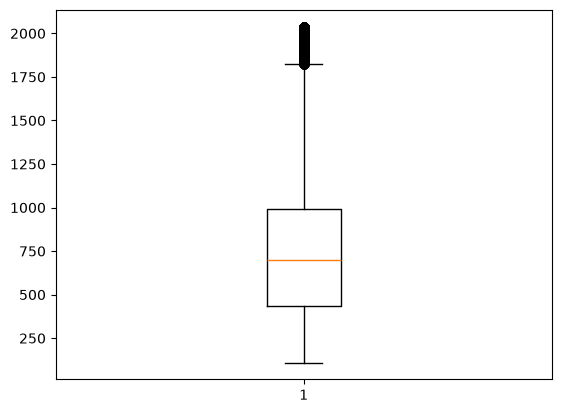

In [24]:
import matplotlib.pyplot as plt

plt.boxplot(df["Current_Price_USD"])
plt.show()

Foram identificados outliers acima de cerca de US$ 1.820, correspondendo aos produtos mais caros do dataset.

In [108]:
outlier = df.loc[df['Current_Price_USD'].idxmax()]

display(outlier[['Model_Name', 'Current_Price_USD']])

Model_Name           MacBook Pro 14-inch M3 Pro 512GB
Current_Price_USD                             2038.97
Name: 21296, dtype: object

## **Análise de negócio**

In [ ]:
# Produtos mais caros recebem avaliações melhores?
# Top 5 produtos mais caros no lançamento
df.drop_duplicates(subset="Model_Name") \
  .sort_values(by="Launch_Price_USD", ascending=False) \
  [["Model_Name", "Condition", "Platform", "Launch_Price_USD"]] \
  .head(5)


,Model_Name,Condition,Platform,Launch_Price_USD
2751,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,Amazon,1999
20138,MacBook Pro 14-inch M3 Pro 512GB,Renewed/Refurbished,Amazon,1999
11382,MacBook Pro 14-inch M2 Pro 512GB,New,Flipkart,1999
37293,MacBook Pro 14-inch M4 Pro 512GB,New,Amazon,1999
8926,iPad Pro 12.9-inch (M2) 256GB,New,Amazon,1199


In [ ]:
# Qual foi o maior preço já registrado?
df.sort_values(by="Current_Price_USD", ascending=False)[["Date", "Model_Name", "Platform", "Sale_Event", "Launch_Price_USD", "Current_Price_USD"]].head(5)

,Date,Model_Name,Platform,Sale_Event,Launch_Price_USD,Current_Price_USD
21797,2023-12-17,MacBook Pro 14-inch M3 Pro 512GB,Amazon,No Promotion,1999,2038.97
21296,2023-12-05,MacBook Pro 14-inch M3 Pro 512GB,Amazon,No Promotion,1999,2038.97
55303,2025-08-19,MacBook Pro 14-inch M4 Pro 512GB,Flipkart,No Promotion,1999,2038.90
54844,2025-08-12,MacBook Pro 14-inch M4 Pro 512GB,Amazon,No Promotion,1999,2038.90
26040,2024-03-27,MacBook Pro 14-inch M3 Pro 512GB,Amazon,No Promotion,1999,2038.83


O MacBook Pro em diferentes datas na Amazon e na FlipKart foi o produto com maior preço atual registrado.

In [109]:
# Eventos promocionais realmente aumentam os descontos?
df.groupby("Sale_Event")["Discount_Pct"].mean()

Sale_Event
Big Billion Days         37.023686
Black Friday             31.462155
Great Indian Festival    33.446077
No Promotion             20.304699
Prime Day                34.435734
Name: Discount_Pct, dtype: float64

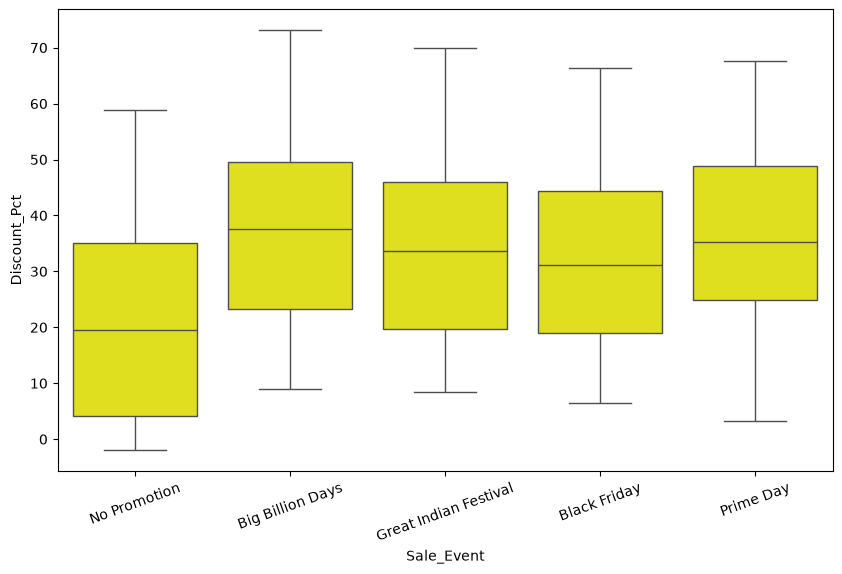

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Sale_Event",
    y="Discount_Pct",
    color='yellow'
)

plt.xticks(rotation=20)
plt.show()

Embora o Big Billion Days apresente o maior desconto médio (37,02%), o boxplot mostra que sua distribuição é bastante semelhante à do Prime Day, que aparece em último na média. As medianas e os intervalos interquartis dos dois eventos são próximos, sugerindo que a diferença observada na média pode ser influenciada por alguns descontos excepcionalmente elevados durante o Big Billion Days (outliers).

In [113]:
# Qual modelo recebe maior desconto (Top 7)?
df.groupby("Model_Name")["Discount_Pct"].mean().sort_values(ascending=False).head(7)

Model_Name
Apple Watch Series 6 (44mm)    34.696112
iPad (9th Gen) 64GB            34.661718
Apple Watch Series 7 (45mm)    33.225500
iPad Air (4th Gen) 64GB        32.537206
iPhone 12 64GB                 30.461596
Apple Watch Series 8 (45mm)    30.049731
iPad Air (5th Gen) 64GB        29.654975
Name: Discount_Pct, dtype: float64

O Apple Watch Series 6 recebe maiores descontos em média

In [73]:
# Qual plataforma vende produtos mais caros (em termos de preço listado)?
plataforma_mais_cara = df.groupby("Platform")["Current_Price_USD"] \
  .mean() \
  .sort_values(ascending=False)

print(plataforma_mais_cara)

Platform
Amazon      783.968025
Flipkart    781.574259
Name: Current_Price_USD, dtype: float64


A plataforma que vende produtos mais caros em média é a Amazon.

## **Visualização**

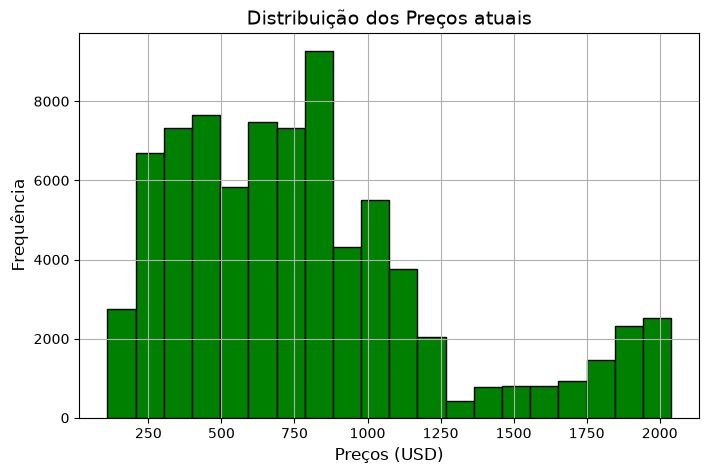

In [95]:
df["Current_Price_USD"].hist(bins=20, edgecolor="black", color='green' ,figsize=(8,5))
plt.title('Distribuição dos Preços atuais', fontsize=14)
plt.xlabel('Preços (USD)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.show()

A maior parte dos produtos comercializados possui preços atuais inferiores a US\$ 1.100, com concentração em torno de US\$ 800–900. Isso pode ser observado também no gráfico de outliers.
#
A distribuição não é uniforme, indicando que os preços não estão distribuídos igualmente entre todas as faixas.

## **Conclusão**
A análise dos descontos por evento promocional mostrou que produtos comercializados durante campanhas apresentam, em média, descontos superiores aos produtos vendidos fora de promoções. O Big Billion Days registrou o maior desconto médio (37,02%), seguido por Prime Day (34,44%), Great Indian Festival (33,45%) e Black Friday (31,46%). Em contraste, produtos sem promoção apresentaram desconto médio de apenas 20,30%.

Entretanto, a análise do boxplot revelou que as distribuições de descontos entre os eventos promocionais são bastante semelhantes. As medianas e os intervalos interquartis do Big Billion Days e do Prime Day, por exemplo, são próximos, indicando que o desconto típico oferecido nesses eventos é semelhante. A diferença observada nas médias pode ser explicada pela presença de alguns descontos excepcionalmente elevados durante o Big Billion Days, que aumentam a média sem alterar significativamente o comportamento geral da distribuição.